# MFIS[1-4] $\rightarrow$ MFIS[5]

In [1]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.model import DMOTransformer, ModelConfig
from src.core.enums import MileStone, PatientDataType, DataFrequency
from src.train import TrainRegression
from src.core.data_transforms import Transform
from src.pipeline.dmo.dmo_into_dataloader import dmo_into_dataloader


import torch


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [26]:
from torch.nn import HuberLoss, CrossEntropyLoss, MSELoss
from torch.optim import Adam, AdamW

config = ModelConfig(
    name="transformer_regression",
    model_type="Transformer",
    batch_size=16,
    epochs=50,
    optimiser=Adam,
    loss_fn=MSELoss(),
    learning_rate=5e-4,
    
    #not used
    input_size=25,
    hidden_size=128,
    num_layers=1,
    output_size=1,
)
config.notes = "None"

transformer_config = {
    "input_features": 176,
    "d_model": 32,
    "nheads": 4,
    "num_layers": 1,
    "dim_feedforward": 4*32,
    "output_size": 1,
    "dropout": 0.1
}

In [4]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
    "total_worn_h",
]

In [5]:
# dmo_features = [
#     "cadence_30_p90_d",
#     "cadence_30_avg_d",
#     "ws_30_p90_d",
#     "strlen_1030_avg_d",
#     "cadence_all_avg_d",
# ]

In [6]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
    #static_features=static_features
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [7]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [8]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, days, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

fatigue_value = dmo_labels[patient_indexs]
dmo_data = dmo_data[patient_indexs]

In [9]:
dmo_data.shape

torch.Size([280, 5, 7, 25])

In [10]:
fatigue_value.shape

torch.Size([280, 5, 1])

In [11]:
# format data
input_data = Transform.format_input_data_lag_label(dmo_data, fatigue_value)
input_data.shape


torch.Size([280, 5, 176])

In [12]:
transforms = (None, None)
training_dl, testing_dl = dmo_into_dataloader(input_data, fatigue_value, batch_size=16, transforms=transforms)

In [28]:
model = DMOTransformer(**transformer_config).to(device=device)
optimiser = config.optimiser(model.parameters(), lr=config.learning_rate)

trainer = TrainRegression(
    model,
    optimiser,
    config,
    training_dl,
    testing_dl,
    device,
    verbose=True,
)

def label_transform(x):
    if len(x.shape) < 3:
        x = x.unsqueeze(dim=0)
    x = x[:, 4, 0]
    return x

def pred_transform(x):
    x = x[:, -1, :]
    x = x.flatten()
    return x

trainer.train_loop(label_transform=label_transform, pred_transform=pred_transform)
prediction, actual = trainer.test_loop(
    label_transform=label_transform, pred_transform=pred_transform
)

Testing loss: 0.041832837741822004


In [29]:
predicted_values = torch.stack(prediction).flatten()
actual_values = torch.stack(actual).flatten()

All metrics: {'accuracy': 0.35714285714285715, 'Mean Squared Error': 0.04010266810655594, 'Mean Absolute Error': 0.1538967788219452, 'R^2': 0.2478100061416626}


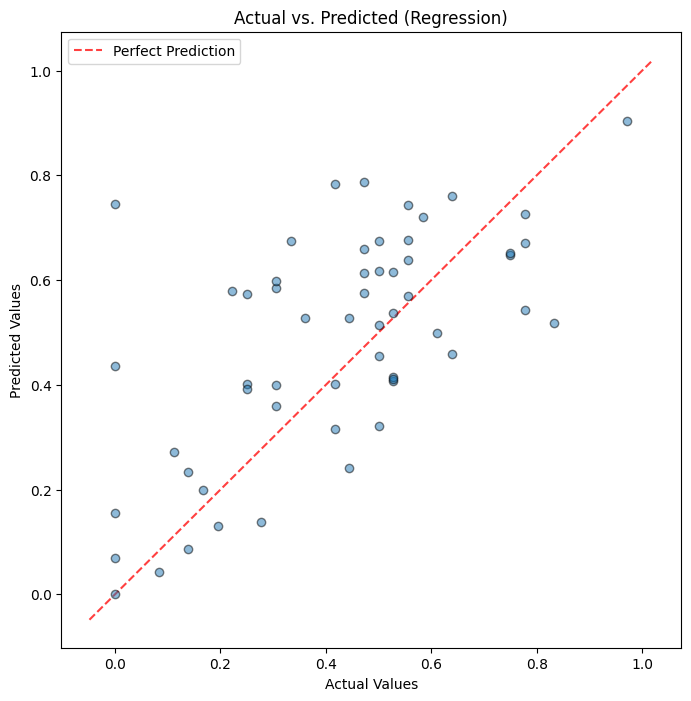

In [30]:
from src.evaluation import Evaluation

evaluation = Evaluation(predicted_values, actual_values)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()